# ERPA Demo: Trajectories, Measures, and Functional Curves

This notebook covers the basics of how to use ERPA, including what's required to use the package and a step-by-step guide through the ananlysis of a single session of data. It loads pose data and a related behavioral logfile, visualizes single-trial and grouped trajectories, and builds the per-trial table of geometric and kinematic measures. It closes with an appendix using Functional Data Analysis (FDA) methods for creating movement-locked curves and elastic curve registration.

Sections:

- Load a session and prepare its trials for plotting.
- Visualize single-trial and grouped trajectories and kinematics.
- Build the per-trial measure table.
- Check the correlation structure among the measures.
- Extract movement-locked curves and runs elastic curve registration on them.

## Imports


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none" # include text as editable objects with specified fonts in saved SVG files
import seaborn as sns
sns.set_theme(style="ticks", context="notebook") # style preferences
from IPython.display import display
from scipy.stats import bootstrap

from erpa.core.session import load_session, prepare_figure_trials
from erpa.fda.functional import run_fpca
from erpa.fda.registration import register_all
from erpa.plotting.corr_clustermap import corr_clustermap
from erpa.plotting.trajectories import plot_trajectories, plot_trial, plot_trajectory_grid, plot_kinematics_grid
from erpa.spatiotemporal.curves import event_locked_curves, movement_curves
from erpa.spatiotemporal.measures import build_measure_table

A design decision was to use accessible colors throughout the package. We use the Okabe-Ito palette. Information about the palette is here:  
https://jfly.uni-koeln.de/color/

In [2]:
OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}

## Paths and settings

The dataset for this tutorial is from a cohort of rats perfoming a 2AFC task in the Laubach Lab. The task is described in a recent preprint from our lab: https://www.biorxiv.org/content/10.1101/2025.10.25.684539.abstract 

The code cell below sets the file paths and settings used through the rest of the notebook. Update the values here for a new session or subject. The current values are for the example dataset included with this notebook.

### File paths

`DATA_DIR` points to the folder holding this session's input files. `OUTPUT_DIR` points to the folder where figures and tables from this notebook are saved. The cell creates `OUTPUT_DIR` if it does not already exist. `SLEAP_FILE` is the path to the SLEAP pose file for this session. `BEHAVIOR_CSV` is the path to the behavioral log for this session.

ERPA was written to use h5 files from SLEAP. If you use other programs or formats, you can convert your files using the **movement** toolbox: https://movement.neuroinformatics.dev/latest/index.html.

### Session synchronization

`FRAME0_TIME` is the video time, in seconds, that lines up the pose tracking clock with the behavioral clock. Find it by locating a shared reference event in the video, such as the first center poke, and noting its timestamp. Each session needs its own value, measured from its own video. `TRIAL_OFFSET` is an integer that corrects a mismatch between the trial numbering in the behavioral CSV and the trial sequence recovered from the pose data. Set it to 0 when the two already agree. A nonzero value is needed when the behavioral log counts trials that were never recorded on video, such as if one or a few trials are performed before the camera was recorded.

### Example trial and event window

`TRIAL_INDEX` selects which trial the single-trial figures in this notebook display. Change it to inspect a different trial. `EVENT_PRE_S` and `EVENT_POST_S` set the window, in seconds, extracted around each aligning event for the event-locked curves. `EVENT_PRE_S` is the time before the event. `EVENT_POST_S` is the time after it.

### Curve registration (appendix)

`FDA_N_POINTS` is the number of points each movement curve is resampled to before registration. All curves share this length, so trials of different duration become directly comparable. `FDA_N_COMPONENTS` sets the number of components used in the elastic registration. `FDA_MAX_ITER` caps the number of iterations the registration runs before it stops, whether or not it has fully converged. Details on the use of FDA in the package are included in the appendix.

In [3]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SLEAP_FILE = DATA_DIR / "pose.h5"
BEHAVIOR_CSV = DATA_DIR / "behavior.csv"

FRAME0_TIME = 5.32 # measured from the video for this example dataset
TRIAL_OFFSET = 0
TRIAL_INDEX = 1

EVENT_PRE_S = 0.5
EVENT_POST_S = 1.0

FDA_N_POINTS = 50
FDA_N_COMPONENTS = 3
FDA_MAX_ITER = 8

## 1. Load the session

The code cell below reads the pose file and the behavioral log for one session. It synchronizes the two using `FRAME0_TIME` and `TRIAL_OFFSET`, then segments the continuous recording into individual trials.

`load_session` returns five objects.

`trials` is a list of per-trial dictionaries. Each dictionary holds the pose and event data for one trial, windowed around that trial's behavioral events.

`behavior` is the per-trial behavioral log as a DataFrame. Each row is one trial.

`series` holds the continuous, whole-session pose measures. It includes the centroid position, head angle, linear velocity, and angular velocity for every frame in the recording, along with the framerate and the pixel-to-centimeter scale.

`ports` gives the location of each port, keyed by name. These positions are estimated from the session's own data and set the spatial scale used throughout the notebook.

`frame0_time` is the synchronization value confirmed by the load. It should match `FRAME0_TIME`. The print statement echoes it back so a mismatch is easy to spot.

`pre_s` and `post_s` are both set to 4.0 seconds here. This is a wide margin, chosen to safely contain the full behavioral window across trials in this tutorial dataset. 

The pre and post times are different from another set of timing limits used below, `EVENT_PRE_S` and `EVENT_POST_S`, that are used for generating the event-locked velocity and heading anlge curves. Two trials had very long intervals between the task events and are excluded below in section 4, where a `UserWarning` is issued.

In [4]:
trials, behavior, series, ports, frame0_time = load_session(
    sleap_file=SLEAP_FILE,
    behavioral_csv=BEHAVIOR_CSV,
    frame0_time=FRAME0_TIME,
    trial_offset=TRIAL_OFFSET,
    pre_s=4.0,
    post_s=4.0,
)

print(f"Loaded {len(trials)} trials")
print(f"Frame-zero time: {frame0_time:.3f} s")
display(behavior.head())

load_behavior_csv dropped 26 of 239 trials with a missing outcome, negative sampling, or sampling/rt above the 95th percentile.
Loaded 213 trials
Frame-zero time: 5.320 s


,name,date,session,time,sampling,rt,cue,target,choice,retrieval,iti,absolute_trial,error
0,demo_rat,2026-07-20,demo,44.374,0.038,0.796,4.0,0.0,0.0,1.600,19.464,1,0
1,demo_rat,2026-07-20,demo,60.014,0.146,0.256,1.0,0.0,0.0,1.374,9.598,3,0
2,demo_rat,2026-07-20,demo,66.122,0.116,0.280,16.0,1.0,1.0,1.280,6.108,4,0
3,demo_rat,2026-07-20,demo,73.422,0.164,1.222,4.0,1.0,0.0,0.894,7.300,5,1
4,demo_rat,2026-07-20,demo,89.588,0.144,0.214,1.0,0.0,0.0,1.198,16.166,6,0


## 2. View the trajectories

`prepare_figure_trials` bridges the canonical trial dictionaries from `load_session` into the fields the plotting functions expect, such as a stacked trajectory arrays. Run it once before any trajectory or kinematics figure in this notebook.

`plot_trajectories` overlays each trial's path on the arena. It draws small multiples, splitting the trials into separate panels rather than one crowded plot.

This call uses the first 100 trials of the session, `figure_trials[:100]`, as a representative sample. `color_by=None` draws every path in a single color, with no grouping by outcome or condition. `show_extrema=False` leaves the velocity extrema unmarked, so the panels show plain paths. `show_full_arena=True` draws the whole arena rather than zooming to the response area alone. `max_trials_per_panel=25` splits the 100 trials into four panels of 25 each, so individual paths stay visible instead of overplotting.

`orientation="paper"` rotates the display so the response ports sit at the top, matching the convention used in our lab's figures. This rotation is for display only. It does not change the underlying trial coordinates or any measure computed from them.

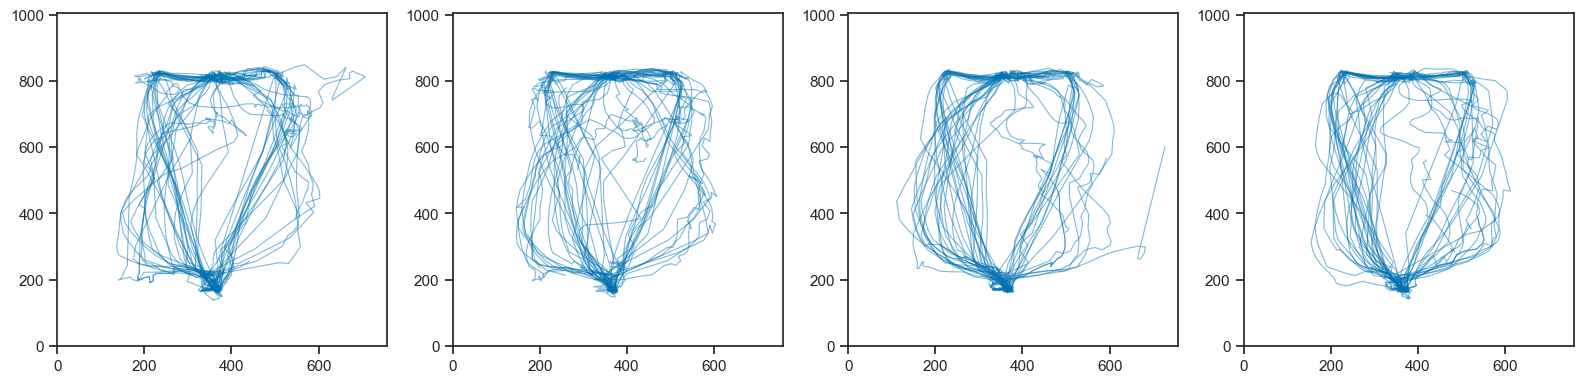

In [5]:
figure_trials = prepare_figure_trials(trials)

fig = plot_trajectories(
    figure_trials[:100],
    color_by=None,
    show_extrema=False,
    show_full_arena=True,
    max_trials_per_panel=25,
    orientation="paper",
)

## 3. View a single trial


`plot_trial` draws a detailed view of one trial, the one set by `TRIAL_INDEX` in the parameters cell. The left panel shows the top-down trajectory, with heading direction and the port locations from `ports`. The right panels show linear and angular velocity over time for that same trial.

`mark_events` adds vertical reference lines for named events across the panels. This call marks `center_entry` and `choice_entry`, so the figure shows when the animal left the center port and when it entered its chosen port.

The keypoints in this dataset were an implanted cannula and the rat's two ears. The distance from the ear line to the snout is typically equal to the distance between our rats' ear. We extend the locations of the response ports forward by this amount, and this is why the keypoints do not enter the ports in the figure.

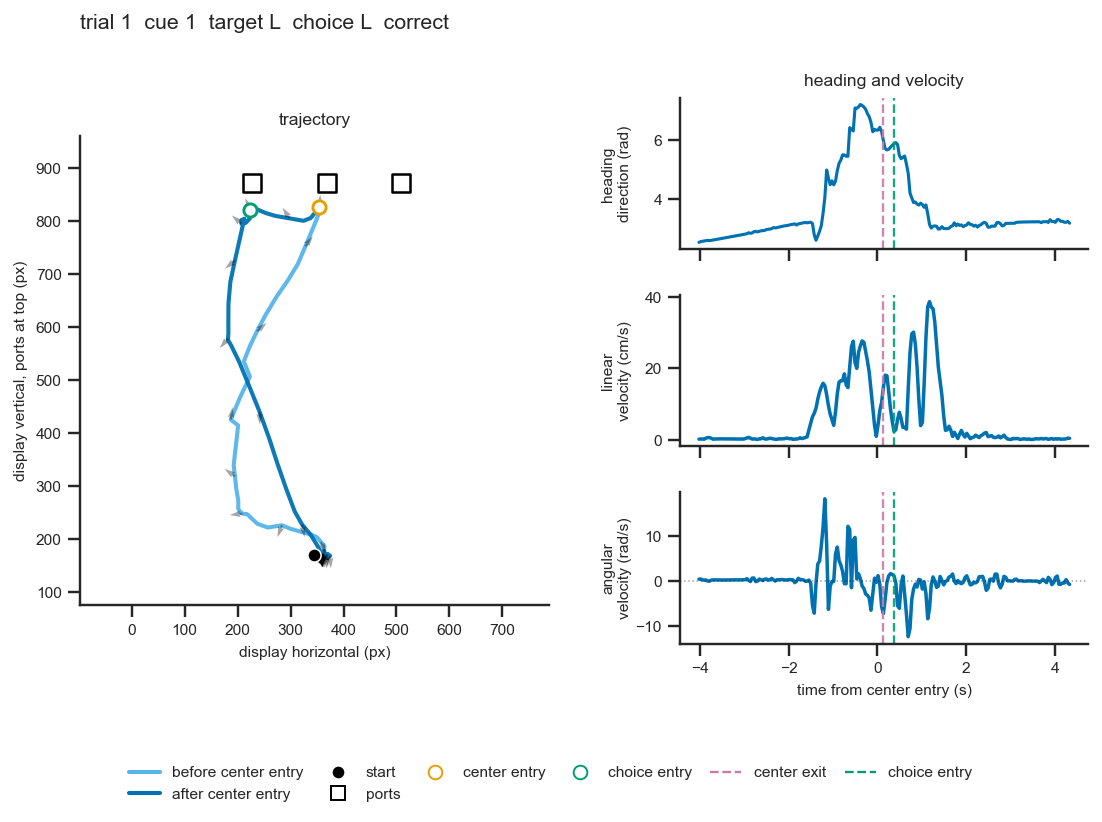

In [6]:
fig = plot_trial(
    trials[TRIAL_INDEX],
    ports=ports,
    mark_events=(
        "center_entry",
        "choice_entry",
    ),
    figsize=(8, 6),
    dpi=140)

## Event-related curve helpers


In [7]:
def plot_mean_ci(ax, t, curves, mask=None, label=None, color=None):
    Y = np.asarray(curves, dtype=float)
    if mask is not None:
        Y = Y[np.asarray(mask)]

    mean = np.nanmean(Y, axis=0)
    ax.plot(t, mean, linewidth=2.2, label=label, color=color)

    if Y.shape[0] >= 3:
        result = bootstrap(
            (Y,),
            np.nanmean,
            axis=0,
            confidence_level=0.95,
            random_state=0,
        )
        ax.fill_between(
            t,
            result.confidence_interval.low,
            result.confidence_interval.high,
            alpha=0.18,
            color=color,
            linewidth=0,
        )

    ax.axvline(0, color=OKABE_ITO["black"], linestyle=":", linewidth=1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## 4. Linear velocity around the four main task events

This cell extracts and plots linear velocity locked to four points in the trial: center entry, center exit, choice entry, and reward entry.

`event_locked_curves` cuts a fixed real-time window around each event, from `EVENT_PRE_S` before it to `EVENT_POST_S` after it, using the linear velocity series (`key="lin_vel"`). It returns the shared time axis `t`, the matrix of per-trial curves `Y`, and `meta`, the trial information aligned row by row with `Y`. The loop stores these three objects in `event_data`, keyed by event name, so later cells in this notebook can reuse them without recomputing.

`plot_mean_ci` draws the mean velocity across trials at each time point, with a shaded confidence band around it. The color comes from the Okabe-Ito palette, chosen for colorblind-safe figures. `sharey=True` keeps all four panels on the same velocity scale, so their shapes and amplitudes stay directly comparable.

/Users/mark.laubach/Desktop/Research/Pose-Estimation-DDMs/Pose Analysis 2026/ERPA/260611/refactor - r1/260720 release/erpa/erpa/spatiotemporal/curves.py:282: UserWarning: event_locked_curves skipped 2 trials whose reward_entry window ran past the trial bounds. Rebuild span trials with larger pre_s or post_s in load_session to make room.
  warnings.warn(


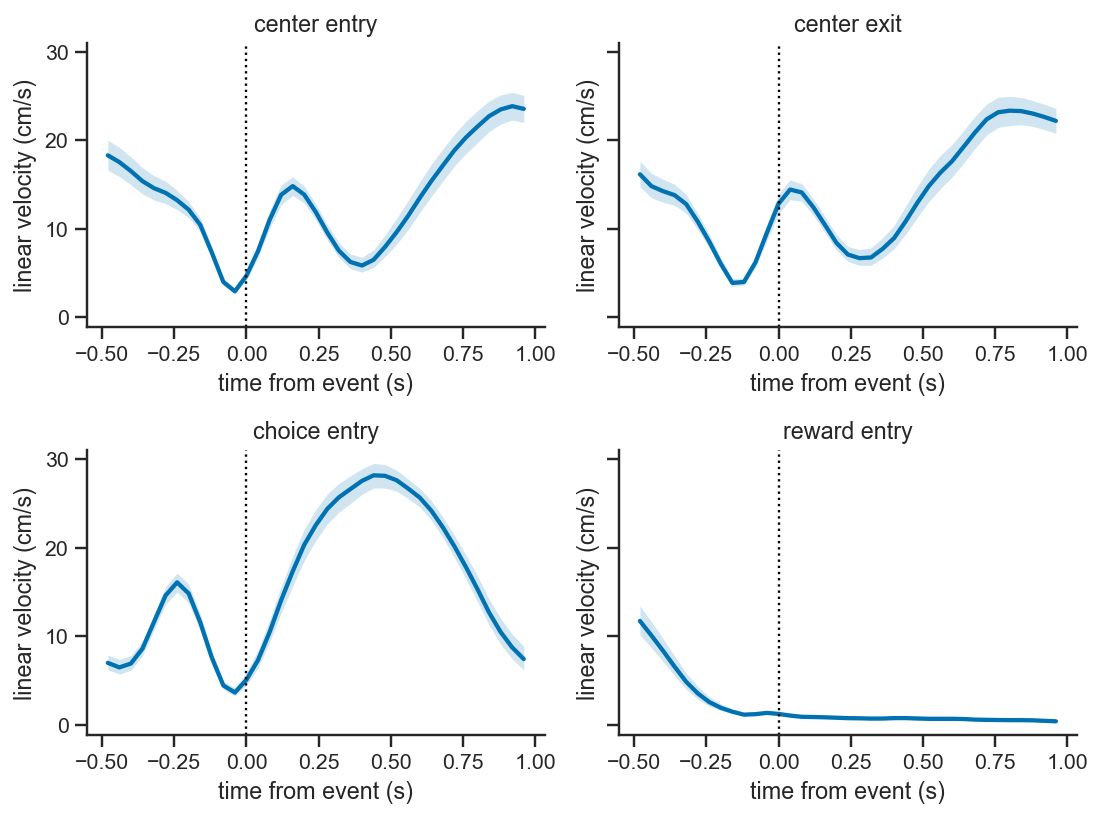

In [8]:
EVENTS = (
    "center_entry",
    "center_exit",
    "choice_entry",
    "reward_entry",
)

event_data = {}

fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=140, sharey=True)

for ax, event in zip(axes.flat, EVENTS):
    t, Y, meta = event_locked_curves(
        trials,
        event=event,
        key="lin_vel",
        pre_s=EVENT_PRE_S,
        post_s=EVENT_POST_S,
    )
    event_data[event] = {"time": t, "curves": Y, "meta": meta}

    plot_mean_ci(
        ax,
        t,
        Y,
        color=OKABE_ITO["blue"],
    )
    ax.set_title(event.replace("_", " "))
    ax.set_xlabel("time from event (s)")
    ax.set_ylabel("linear velocity (cm/s)")

fig.tight_layout()

## 5. Compare fast and slow trials at center exit

This cell reuses the center-exit curves computed in the previous cell, stored in `event_data["center_exit"]`, rather than calling `event_locked_curves` again.

The trials are split into terciles by reaction time. `fast` marks trials at or below the bottom third. `slow` marks trials at or above the top third. The middle third is left out of both groups, so the comparison contrasts the two tails rather than a full median split.

`plot_mean_ci` is called twice, once per group, each with its own boolean mask and its own color from the Okabe-Ito palette. The shaded band is a bootstrap confidence interval, the reason `scipy.stats.bootstrap` appears in this notebook's imports. The legend reports how many trials fall in each group.

Comparing the two curves shows whether fast and slow trials differ in the shape of the movement around center exit, not only in how long the rat took to move.

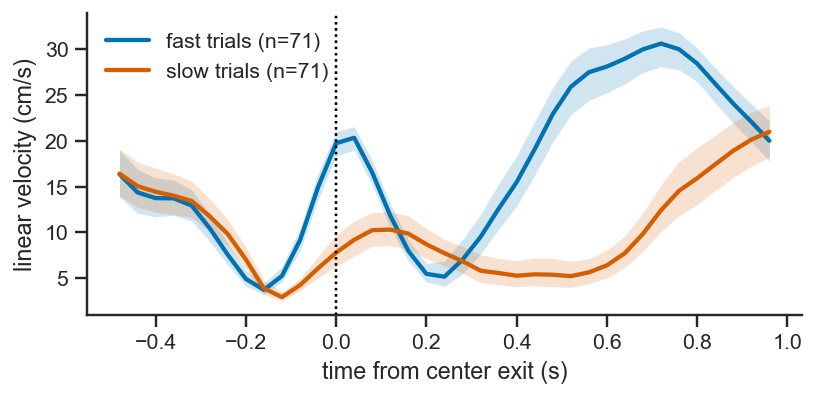

In [9]:
center_exit = event_data["center_exit"]
rt = center_exit['meta']['rt']
lower, upper = rt.quantile([1 / 3, 2 / 3])

fast = rt <= lower
slow = rt >= upper

fig, ax = plt.subplots(figsize=(6, 3), dpi=140)

plot_mean_ci(
    ax,
    center_exit["time"],
    center_exit["curves"],
    fast,
    label=f"fast trials (n={fast.sum()})",
    color=OKABE_ITO["blue"],
)
plot_mean_ci(
    ax,
    center_exit["time"],
    center_exit["curves"],
    slow,
    label=f"slow trials (n={slow.sum()})",
    color=OKABE_ITO["vermillion"],
)

ax.set_xlabel("time from center exit (s)")
ax.set_ylabel("linear velocity (cm/s)")
ax.legend(frameon=False)
fig.tight_layout()

## 6. Save the event-related curves

The compressed arrays contain one row per trial. The metadata files contain the trial identifiers and labels. ROCKET-family classifiers can use the full curves, while shapelet methods can identify discriminative subsequences. The `tsc` module in `extras/tsc` provides code to run these time-series classifiers. 


In [10]:
for event, result in event_data.items():
    np.savez_compressed(
        OUTPUT_DIR / f"lin_vel_{event}.npz",
        time=result["time"],
        curves=result["curves"],
    )
    result["meta"].to_csv(
        OUTPUT_DIR / f"lin_vel_{event}_metadata.csv",
        index=False,
    )

X_center_exit = center_exit["curves"][:, np.newaxis, :]
print("Time-series array:", X_center_exit.shape)

Time-series array: (213, 1, 37)


## 7. Build the scalar measure table with FDA lag

### Measures in the per-trial table

`build_measure_table` returns one row per trial. Each row holds geometric and kinematic measures computed over the decision movement, the path from center exit to choice entry. Distances are in centimeters. Times are in seconds from center exit.

#### Path shape

`dev_unchosen_cm` and `dev_unchosen_norm` measure how far the path swings toward the unchosen port before the animal commits to its final choice. `t_dev` marks the time of that maximum swing. `path_len_cm` and `path_len_norm` measure total distance traveled. `tortuosity` is the ratio of path length to straight-line displacement. A direct run to the port gives a tortuosity near one. A wavering run gives a higher value.

#### Velocity and timing

`peak_lin_vel` is the fastest linear velocity reached during the movement. `t_peak_lin_vel` is the time from center exit to that peak. `vel_choice` is the linear velocity at the moment of choice entry. `peak_ang_vel` is the fastest angular velocity of the head over the same window. `ang_peak_lag` is the time offset between the angular velocity peak and the linear velocity peak.

#### Heading and commitment

`head_to_chosen` is the heading angle toward the chosen port. It is measured at a fixed point early along the path rather than a fixed time, so it stays comparable across trials that move at different speeds. `t_commit` marks the spatial midpoint of the movement. `t_choice` is the total duration of the decision movement, and should have a very high correlation with the recorded reaction time from the behavioral control system used for the experiment.

#### Behavioral scalars

`sampling` and `RT` describe trial timing before and during the decision. `sampling` is specific to recent experiments in our lab, where we require rats to maintain a response in the center port to display the task stimuli. These behavioral measures are kept in the table as measures, not as labels, because they carry continuous information rather than a task condition. 

#### FDA lag

When `add_fda=True`, curve registration adds functional measures to the table. `fda_lag` is the signed area between a trial's warping function and the identity line. A positive value means the trial's full movement trajectory was slow relative to the registered template. A negative value means it was shifted to the left and thus a fast trial. `fda_score1`, `fda_score2`, and further columns are amplitude fPCA scores. They summarize the shape of the registered velocity curve relative to the other curves in the same call. These can be useful additional measures, but are session specific and should not be used in hierarchical analysis such as fitting sequential sampling models with HSSM or hierarchical logistic regression with bambi. A trial dropped from registration keeps its row in the table, with `NaN` in the FDA columns.

In [11]:
measure_table, exclusions = build_measure_table(
    trials,
    ports,
    node="centroid",
    add_fda=True,
    key="lin_vel",
    n_points=FDA_N_POINTS,
    max_iter=FDA_MAX_ITER,
    return_exclusions=True,
)

print("Measure table:", measure_table.shape)
print("Scalar-only trials:", len(exclusions["scalar_only"]))
print("FDA-only trials:", len(exclusions["fda_only"]))
display(measure_table.head())

Measure table: (213, 24)
Scalar-only trials: 0
FDA-only trials: 0


,idx,absolute_trial,target,choice,trial_type,error,cue,sampling,rt,vel_choice,...,t_choice,t_commit,dev_unchosen_cm,dev_unchosen_norm,t_dev,head_to_chosen,tortuosity,path_len_cm,path_len_norm,fda_lag
0,0,1,0,0,NaN,0,4.0,0.038,0.796,5.342886,...,0.80,0.60,2.620215,0.694227,0.12,0.353855,1.474086,7.035162,1.863969,-0.185138
1,1,3,0,0,NaN,0,1.0,0.146,0.256,2.272035,...,0.24,0.08,-1.002397,-0.265585,0.00,0.584173,1.000303,2.201232,0.583217,0.041098
2,2,4,1,1,NaN,0,16.0,0.116,0.280,3.504469,...,0.28,0.08,-0.771936,-0.182676,0.00,0.630197,1.012042,2.302713,0.544930,-0.074733
3,3,5,1,0,NaN,1,4.0,0.164,1.222,3.668727,...,1.24,0.12,0.097239,0.025763,0.00,0.615987,3.005805,10.325795,2.735823,-0.165305
4,4,6,0,0,NaN,0,1.0,0.144,0.214,0.349254,...,0.20,0.04,-1.336384,-0.354075,0.00,0.677050,1.000255,1.592015,0.421805,-0.004902


## 8. Correlation structure among the measures

`MEASURE_CANDIDATES` lists the behavioral, kinematic, and functional measures worth checking for redundancy before any modeling. The loop below keeps only the names that are actually present as columns in `measure_table`, in the order listed, and drops duplicates. This keeps the cell safe to rerun on tables built with or without FDA measures, since `fda_lag` simply drops out when `add_fda=False`.

`corr_clustermap` computes the Pearson correlation between every pair of measures in `measures`, then reorders the rows and columns by hierarchical clustering on 1 minus the absolute correlation. Measures that move together land next to each other, so correlated groups show up as blocks along the diagonal. The color encodes the signed correlation, and a dendrogram across the top shows the clustering that set the order. `method="average"` sets the linkage rule for that clustering. `peak_ang_vel` is converted to its absolute value before this correlation, since its raw sign only reflects turn direction rather than movement strength.

`fig` is the clustermap figure itself. `info` carries the details behind it: the measure order after clustering, the linkage matrix, the final measure list, and a group label per measure when `n_groups` is set. This example leaves `n_groups` unset, so no extra grouping is drawn beyond the dendrogram.

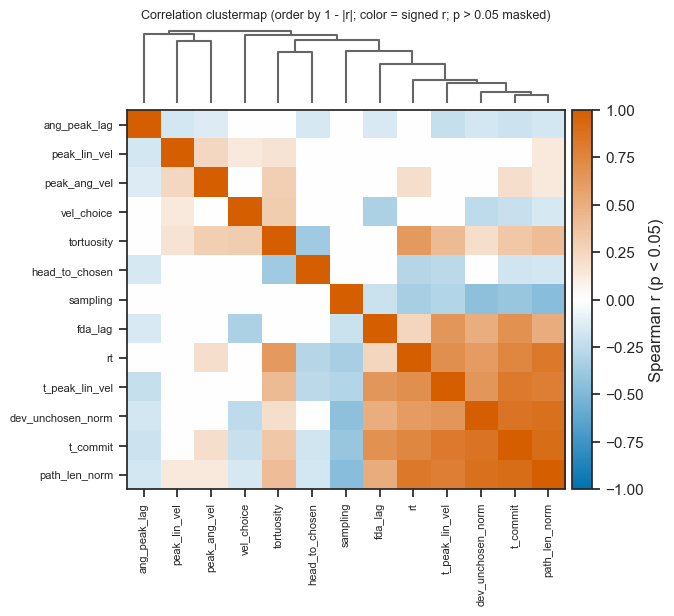

In [12]:
MEASURE_CANDIDATES = [
    "sampling",
    "rt",
    "peak_lin_vel",
    "peak_ang_vel",
    "t_peak_lin_vel",
    "ang_peak_lag",
    "vel_choice",
    "t_commit",
    "dev_unchosen_norm",
    "head_to_chosen",
    "tortuosity",
    "path_len_norm",
    "fda_lag",
]

measures = []
for name in MEASURE_CANDIDATES:
    if name in measure_table.columns and name not in measures:
        measures.append(name)

fig, info = corr_clustermap(
    measure_table,
    measures=measures,
    method="average",
    figsize=(6, 6), 
)

The dendrogram groups the measures into three main clusters, plus one measure that stands apart from everything else.

The largest cluster includes `fda_lag`, `rt`, `t_peak_lin_vel`, `dev_unchosen_norm`, `t_commit`, and `path_len_norm`. These measures are strongly correlated with each other. A trial with a longer reaction time also tends to show a later peak-velocity time, a larger deviation toward the unchosen port, a later commitment point, and a longer overall path. `fda_lag` sits inside this same cluster, next to the scalar timing measures it was built to complement. `sampling` joins this cluster too, but through a strong negative relationship rather than a positive one. 

`tortuosity` and `head_to_chosen` merge as a second, separate pair, describing the shape and heading of the path rather than its speed.

`peak_lin_vel`, `peak_ang_vel`, and `vel_choice` form a third cluster. These three describe how fast the movement was, at its peak and at the moment of choice. 

These two small clusters join together at a moderate distance, forming a broader group built from the quality of the movement rather than its duration.

`ang_peak_lag` stands apart from every other measure and joins the tree last, at the very top of the dendrogram. Its correlations with the rest of the table sit close to zero. This independence is worth noting on its own. Unlike a measure that turns out to be redundant with something already in the table, `ang_peak_lag` is carrying information none of the others capture.

## 9. Pairwise relationships among key measures

This cell checks four measures together: reaction time, sampling time, peak linear velocity, and normalized deviation toward the unchosen port. `rt_measure` resolves the reaction-time column name once. `pair_variables` collects the four names, then keeps only the ones actually present in `measure_table`.

`plot_data` prepares the values for plotting. It selects these four columns, replaces any infinite values with `NaN`, then drops rows with a missing value in any of them. A trial only appears in the grid if it has a complete set of values across all four measures.

`sns.pairplot` draws every pairwise relationship as a small scatter plot, with a histogram of each single measure along the diagonal.


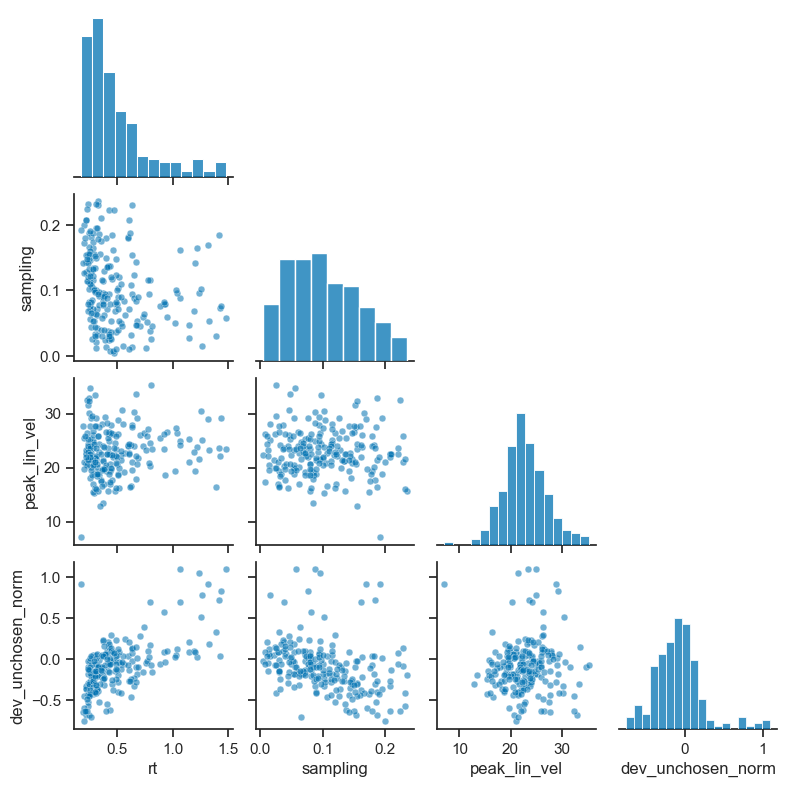

In [13]:
pair_variables = [
    "rt",
    "sampling",
    "peak_lin_vel",
    "dev_unchosen_norm",
]
pair_variables = [
    name for name in pair_variables
    if name in measure_table.columns
]

plot_columns = pair_variables
plot_data = (
    measure_table[plot_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

grid = sns.pairplot(
    plot_data,
    vars=pair_variables,
    corner=True,
    diag_kind="hist",
    plot_kws={"s": 24, "alpha": 0.55, "color": "#0072B2"},
    diag_kws={"color": "#0072B2"},  # for the diagonal distribution plots
    height=2,
)

## 10. Explore single-trial trajectories based on the scalar measures

`plot_trajectory_grid` lets you inspect specific trials in the session side by side. A useful case is comparing the trials with the largest and smallest values of a given scalar measure. Here we compare the trials with the largest and smallest deviation toward the unchosen option.

### Why deviation toward the unchosen option matters

`dev_unchosen_norm` measures how far the trajectory swings toward the port the animal did not choose, at the point of its largest excursion. The value is normalized by the distance to the chosen port, so it is comparable across trials and across sessions.

This measure connects directly to a well-established finding in the decision-making literature. Resulaj, Kiani, Wolpert, and Shadlen (2009) showed that reach trajectories can reveal a partial commitment to an option that is ultimately rejected, evidence that the decision process keeps running after the movement itself has started. A high `dev_unchosen_norm` marks a trial where the path carries a visible trace of that competing option before the animal settles on its final choice. A low value marks a trial that moved directly to the chosen port with little sign of the alternative.

Resulaj, A., Kiani, R., Wolpert, D. M., & Shadlen, M. N. (2009). Changes of mind in decision-making. *Nature*, *461*(7261), 263-266.

,sampling,rt,peak_lin_vel,peak_ang_vel,t_peak_lin_vel,ang_peak_lag,vel_choice,t_commit,dev_unchosen_norm,head_to_chosen,tortuosity,path_len_norm,fda_lag
43,0.088,1.062,24.962896,-24.252901,0.52,0.04,0.630203,0.84,1.095009,-0.396962,2.546999,3.010183,0.112224
115,0.200,0.200,21.011369,-15.126107,0.00,0.00,10.042010,0.00,-0.758232,0.648876,1.015703,0.201127,-0.119310


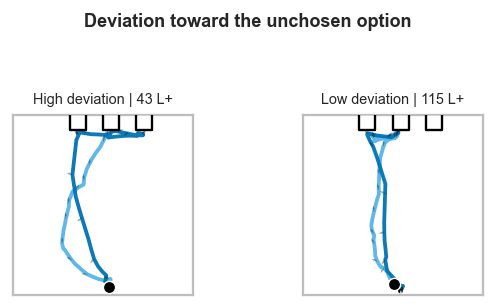

In [14]:
# Find the largest and smallest dev_unchosen_norm
dev_max_idx = measure_table["dev_unchosen_norm"].idxmax()
dev_min_idx = measure_table["dev_unchosen_norm"].idxmin()
display(measure_table.loc[[dev_max_idx, dev_min_idx], MEASURE_CANDIDATES])

tr_dev_unchosen_max = measure_table["idx"].loc[dev_max_idx]
tr_dev_unchosen_min = measure_table["idx"].loc[dev_min_idx]

# Plot trajectories for the trials
fig = plot_trajectory_grid(
    trials, ports, n_cols=2,
    trial_indices=[tr_dev_unchosen_max, tr_dev_unchosen_min],
)

labels = ["High deviation", "Low deviation"]
for label, ax in zip(labels, fig.axes):
    current_title = ax.get_title()
    ax.set_title(f"{label} | {current_title}", fontsize=8)

fig.suptitle("Deviation toward the unchosen option", fontsize=10, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])  # make room for the suptitle

## 11. Save the scalar table

The table can be used for PCA, cluster analysis, tabular classification, hierarchical regression, or drift-diffusion modeling.

Examples of applying these methods to ERPA data are provided in the `extra` directory in our repository.


In [15]:
measure_table.to_csv(
    OUTPUT_DIR / "erpa_measure_table.csv",
    index=False,
)

---

## Appendix: Elastic curve registration

Trial duration varies. If you average velocity curves without accounting for that, trials that peak at slightly different times blur together, and the average looks lower and wider than any single trial actually was. Elastic curve registration separates two things that a raw average mixes: the shape of the movement and its timing.

The method works by finding a time-warping function for each trial that aligns it to a common template (i.e., the average response over all trials). Once every trial's timing is aligned to the same template, the registered curves isolate the shape differences alone. The warping function itself isolates the timing difference alone, as a curve rather than a single number.

This appendix runs that registration on the linear-velocity movement curves and shows what it recovers. `register_all` is the same function `build_measure_table` calls internally when `add_fda=True`, so this walks through, step by step, where the `fda_lag` column in the main measure table comes from.

### Extract the movement curves

`movement_curves` resamples each trial's center-exit-to-choice-entry velocity trace onto a common normalized time axis, `movement_grid`, with `FDA_N_POINTS` samples. Real duration is discarded at this step. A trial that took 0.4 seconds and a trial that took 0.7 seconds both end up as curves of the same length, so their shapes become directly comparable. `movement_velocity` holds one resampled curve per trial. `movement_meta` carries the trial information aligned to each row.

In [16]:
movement_grid, movement_velocity, movement_meta = movement_curves(
    trials,
    key="lin_vel",
    n_points=FDA_N_POINTS,
)

### Run the registration

`register_all` finds one common template, the Karcher mean, and aligns every curve to it. It returns `fn`, the registered curves, and `gam`, the warping function for each trial. `fn` and `gam` share the same shape as the input, one row per trial, but they now carry different information: `fn` is shape with timing removed, `gam` is timing alone, expressed as each trial's own path from its raw time axis to the template's time axis.

`phase_joint=False` skips two additional score types, phase and joint fPCA, that this tutorial does not cover. The registered curves and warping functions used below do not depend on that setting.

In [17]:
registration = register_all(
    movement_grid,
    movement_velocity,
    n_comp=FDA_N_COMPONENTS,
    max_iter=FDA_MAX_ITER,
    phase_joint=False,
)
print("Raw curves:", movement_velocity.shape)
print("Registered curves:", registration["fn"].shape)
print("Warping functions:", registration["gam"].shape)

Raw curves: (213, 50)
Registered curves: (213, 50)
Warping functions: (213, 50)


### Results

The left panel shows the raw curves, each trial in gray with the mean in blue. Because trials reach peak velocity at slightly different times, the mean sits lower and wider than any individual trial.

The middle panel shows the same trials after registration. Once timing is aligned, the individual curves overlap more tightly, and the mean is a sharper, more representative shape.

The right panel shows what changed to get there. Each gray line is one trial's warping function, its own mapping from raw time to the template's time. The blue diagonal is the identity line, a trial with no timing shift at all. A warping function that bows above the identity ran later than the template at that point in the movement. One that bows below ran earlier. `fda_lag`, in the main measure table, is the signed area between a trial's warping function and this identity line, a single number summarizing the bow in this right-hand panel.

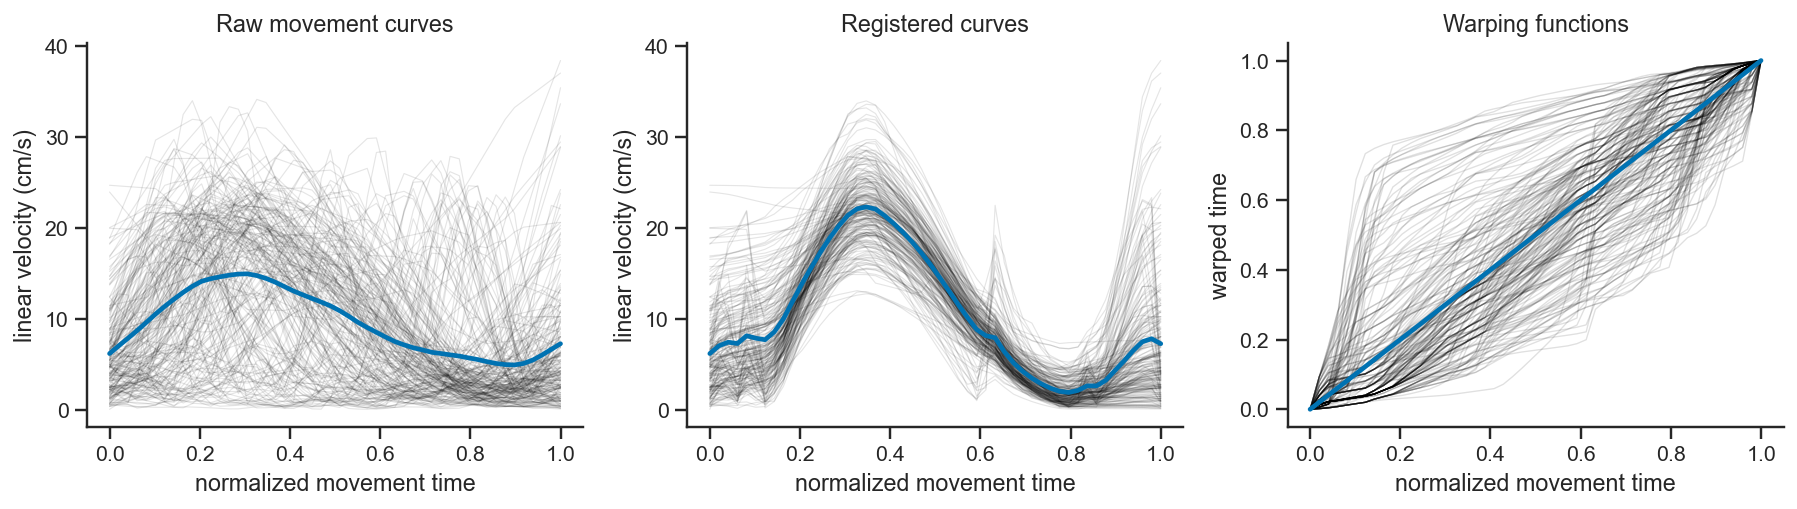

In [18]:
# compare raw curves, registered curves, and warping functions
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=140)

axes[0].plot(movement_grid, movement_velocity.T,
            color=OKABE_ITO["black"], alpha=0.10, linewidth=0.6)
axes[0].plot(movement_grid, np.nanmean(movement_velocity, axis=0),
            color=OKABE_ITO["blue"], linewidth=2.4)
axes[0].set_title("Raw movement curves")

axes[1].plot(movement_grid, registration["fn"].T,
            color=OKABE_ITO["black"], alpha=0.10, linewidth=0.6)
axes[1].plot(movement_grid, np.nanmean(registration["fn"], axis=0),
            color=OKABE_ITO["blue"], linewidth=2.4)
axes[1].set_title("Registered curves")

axes[2].plot(movement_grid, registration["gam"].T,
            color=OKABE_ITO["black"], alpha=0.12, linewidth=0.7)
axes[2].plot(movement_grid, movement_grid,
            color=OKABE_ITO["blue"], linewidth=2.4)
axes[2].set_title("Warping functions")

for ax in axes:
    ax.set_xlabel("normalized movement time")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("linear velocity (cm/s)")
axes[1].set_ylabel("linear velocity (cm/s)")
axes[2].set_ylabel("warped time")
fig.tight_layout()

## A2. FDA lag

`fda_lag` is the signed area between a trial's warping function and the identity line. It can be analyzed with the behavioral, geometric, and kinematic measures in the scalar table.

`measure_table`'s `fda_lag` column is from `build_measure_table`'s own internal call to `register_all`. This cell reruns that registration explicitly, on the curves already extracted above, so the packaged value can be checked against a direct one rather than simply trusted.

In [19]:
fda_detail = pd.DataFrame({
    "idx": movement_meta["idx"].astype(int).to_numpy(),
    "fda_lag_direct": registration["lag"],
    "fda_amp1_direct": registration["amp"][:, 0],
})
fda_with_scalars = measure_table.merge(
    fda_detail,
    on="idx",
    how="left",
)
lag_variables = [
    name for name in (
        "fda_lag",
        "fda_lag_direct",
        "rt",
        "sampling",
        "peak_lin_vel",
        "dev_unchosen_norm",
    )
    if name in fda_with_scalars.columns
]
display(
    fda_with_scalars[lag_variables]
    .corr(method="spearman")
    .round(2)
)

,fda_lag,fda_lag_direct,rt,sampling,peak_lin_vel,dev_unchosen_norm
fda_lag,1.00,1.00,0.25,-0.20,-0.05,0.50
fda_lag_direct,1.00,1.00,0.25,-0.20,-0.05,0.50
rt,0.25,0.25,1.00,-0.34,0.06,0.62
sampling,-0.20,-0.20,-0.34,1.00,0.01,-0.44
peak_lin_vel,-0.05,-0.05,0.06,0.01,1.00,0.11
dev_unchosen_norm,0.50,0.50,0.62,-0.44,0.11,1.00


`fda_detail` holds two outputs of this appendix's own registration run, keyed by trial `idx`: `fda_lag_direct`, the signed warping lag, and `fda_amp1_direct`, the first amplitude fPCA score. `fda_with_scalars` merges these onto the full measure table, so every comparison below draws from one table.

`lag_variables` keeps only the names that actually exist in `fda_with_scalars`, then the cell displays their Spearman correlations. The correlation between `fda_lag` and `fda_lag_direct` is the key check: a value at or very near 1 confirms the packaged measure and this appendix's own run agree. The rest of the matrix shows how the timing lag relates to reaction time, sampling time, peak velocity, and deviation.

### Distribution and relation to reaction time

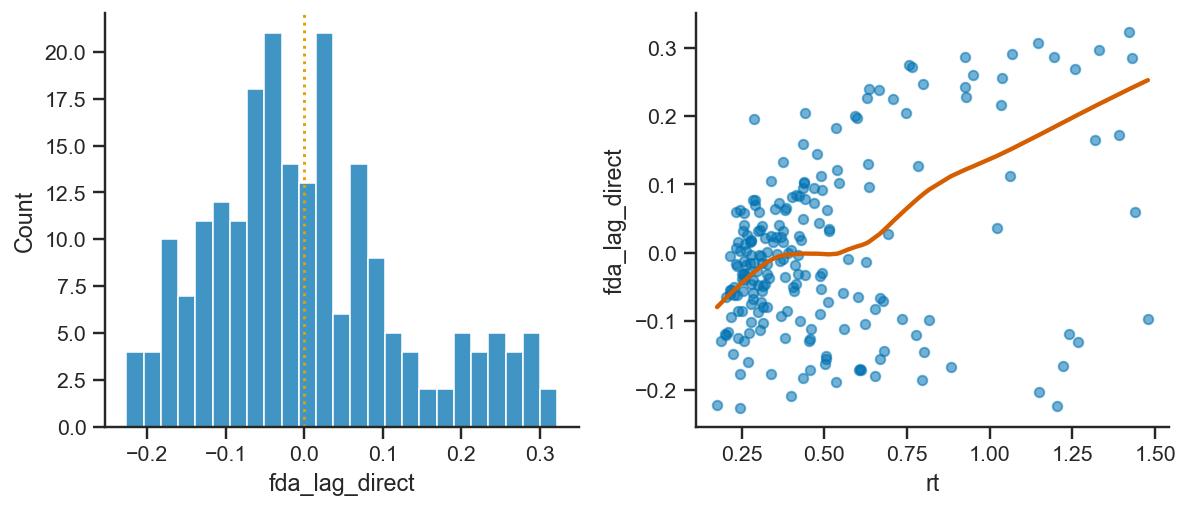

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8.67, 3.8), dpi=140)
sns.histplot(
    data=fda_with_scalars,
    x="fda_lag_direct",
    bins=25,
    ax=axes[0],
    color=OKABE_ITO["blue"],
)
axes[0].axvline(0, color=OKABE_ITO["orange"], linestyle=":")
sns.regplot(
    data=fda_with_scalars,
    x="rt",
    y="fda_lag_direct",
    lowess=True,
    ax=axes[1],
    scatter_kws={"color": OKABE_ITO["blue"], "s": 24, "alpha": 0.55},
    line_kws={"color": OKABE_ITO["vermillion"]},
)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()

The left panel shows the distribution of `fda_lag_direct` across all trials. The dashed line at zero marks no timing shift relative to the registration template. Trials to the right ran later than the template; trials to the left ran earlier. The shape of this distribution, centered or skewed, is worth checking before treating `fda_lag` as a regressor.

The right panel plots `fda_lag_direct` against reaction time, with a local trend line rather than a straight-line fit, so any curvature in the relation stays visible.

### Relation to other timing landmarks

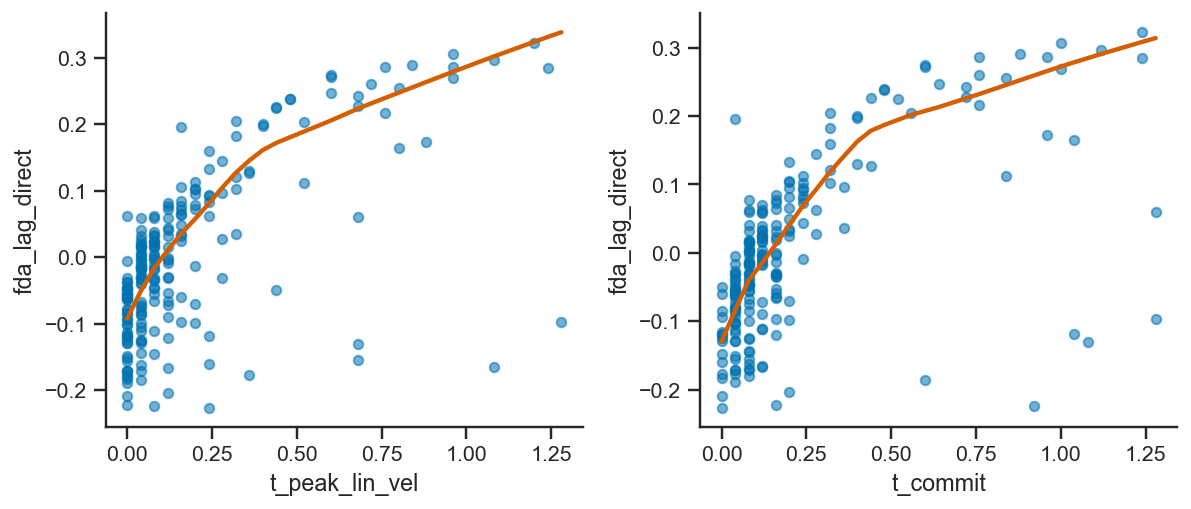

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(8.67, 3.8), dpi=140)
sns.regplot(
    data=fda_with_scalars,
    x="t_peak_lin_vel",
    y="fda_lag_direct",
    lowess=True,
    ax=axes[0],
    scatter_kws={"color": OKABE_ITO["blue"], "s": 24, "alpha": 0.55},
    line_kws={"color": OKABE_ITO["vermillion"]},
)
sns.regplot(
    data=fda_with_scalars,
    x="t_commit",
    y="fda_lag_direct",
    lowess=True,
    ax=axes[1],
    scatter_kws={"color": OKABE_ITO["blue"], "s": 24, "alpha": 0.55},
    line_kws={"color": OKABE_ITO["vermillion"]},
)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()

These two panels check `fda_lag_direct` against two timing landmarks already in the scalar table. `t_peak_lin_vel` is the time from center exit to peak velocity. `t_commit` is the time of the movement's spatial midpoint. A tight relation with either would mean `fda_lag` mostly restates timing information already available from these simpler, more directly interpretable landmarks. A weak relation would mean it is contributing timing information the scalar landmarks do not capture on their own.

## A3. Functional curves and time-series classification

Raw curves retain phase and amplitude differences. Registered curves reduce phase variability and emphasize amplitude and shape. Either representation can be supplied to ROCKET-family or shapelet classifiers, depending on the scientific question. Preprocessing and feature extraction should be fit within each cross-validation fold.


In [22]:
# Reshape to (n_trials, n_channels, n_timepoints), the shape time-series classifiers expect 
X_raw = movement_velocity[:, np.newaxis, :]
X_registered = registration["fn"][:, np.newaxis, :]
print("Raw functional array:", X_raw.shape)
print("Registered functional array:", X_registered.shape)

# Save the data to disk
np.savez_compressed(
    OUTPUT_DIR / "fda_movement_curves.npz",
    grid=movement_grid,
    raw=movement_velocity,
    registered=registration["fn"],
    warping=registration["gam"],
    lag=registration["lag"],
    amp_scores=registration["amp"],
    n_points=FDA_N_POINTS,
    n_components=FDA_N_COMPONENTS,
    max_iter=FDA_MAX_ITER,
)
movement_meta.to_csv(
    OUTPUT_DIR / "fda_movement_metadata.csv",
    index=False,
)

Raw functional array: (213, 1, 50)
Registered functional array: (213, 1, 50)


Row `i` in every array inside `fda_movement_curves.npz` matches row `i` in `fda_movement_metadata.csv`. Anyone loading the `.npz` file on its own can recover each trial's identity and behavioral labels through this shared row order.